**Inputs**

The notebook reads these files:
`ukb_ground_truth_positive_labelled.csv`

Every valid row is treated as a positive example (label=1): the paper used UK Biobank data or resources.

And

`ukb_negative_pre2014_labelled.csv`

Every valid row is treated as a negative example (label=0): the paper did not use UK Biobank data or resources.

**Output**

The notebook saves the sampled evaluation set, per-prompt predictions and raw model outputs, performance tables, pairwise agreement tables and heatmaps, and a final ranking to `/ukb_prompt_eval_outputs_v2.`

In [ ]:


!pip -q install -U transformers accelerate sentencepiece tqdm sentence-transformers huggingface_hub bitsandbytes scikit-learn matplotlib

import os, re, json, time, gc, getpass, ast, random, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModel, BitsAndBytesConfig
from sentence_transformers import SentenceTransformer
from huggingface_hub import login
from google.colab import drive

warnings.filterwarnings("ignore")

drive.mount("/content/drive")



In [ ]:
# ============================================================
# Hugging Face login
# ============================================================

hf_token = os.getenv("HF_TOKEN", "").strip()
if not hf_token:
    try:
        hf_token = getpass.getpass("Hugging Face token, press Enter to skip: ").strip()
    except Exception:
        hf_token = ""

if hf_token:
    os.environ["HF_TOKEN"] = hf_token
    login(token=hf_token)
    print("HF login: done.")
else:
    print("HF login: skipped.")

# ============================================================
# Paths and config
# ============================================================

TP_PATH = "/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_ground_truth_positive_labelled.csv"
TN_PATH = "/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_negative_pre2014_labelled.csv"

OUT_DIR = "/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2"
os.makedirs(OUT_DIR, exist_ok=True)

N_POS = ANY NUMBER
N_NEG = ANY NUMBER
SEED = 42
USE_4BIT = True

print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 72.5 MB/s eta 0:00:00


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
HF login: done.
CUDA: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
TP pool: 10696 unique ids: 10696
TN pool: 6083 unique ids: 6083
Eval set: (400, 6)
label
0    200
1    200
Name: count, dtype: int64
Saved eval set: /content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/ukb_eval_200pos_200neg.csv


,id,title,abstract,year,label,True_label
0,pub.1057244722,Herausforderungen des Biobankings in der tägli...,Einleitung Erklärtes Ziel der translationalen ...,2012.0,0,False
1,pub.1091782488,Identification of a Genomic Signature Predicti...,The first year of the grant required: IRB appr...,2013.0,0,False
2,pub.1132367329,Confidence Sets for Cohen’s d effect size images,Current statistical inference methods for task...,2020.0,1,True
3,pub.1060336526,Breast cancer risk linked to alcohol consumpti...,&NA; ▪ Studies presented at the Meeting showed...,2008.0,0,False
4,pub.1134737664,Assessing Lung Cancer Absolute Risk Trajectory...,Lung cancer is the leading cause of cancer-rel...,2021.0,1,True
5,pub.1138945455,A unified framework identifies new links betwe...,Plasma lipids are known heritable risk factors...,2021.0,1,True
6,pub.1010318796,Human Papillomavirus Type 16 Genetic Variants:...,Naturally occurring genetic variants of human ...,2012.0,0,False
7,pub.1183123033,Causes and Consequences of Clonal Hematopoiesi...,"Introduction: Clonal hematopoiesis (CH), the e...",2024.0,1,True
8,pub.1008069687,Studying potential donors' views on embryonic ...,Embryo experimentation raises many ethical que...,2006.0,0,False
9,pub.1144549084,Early prediction of decompensation (EPOD) scor...,"BACKGROUND & AIMS: <AbstractText Label=""BACKGR...",2022.0,1,True



One-shot positive example:


...

,model,prompt,type,runtime_s,items_per_sec,parse_rate,n_parsed,accuracy,precision,recall,f1,tp,tn,fp,fn,error,threshold,calib_f1_all_eval
0,qwen2_5_7b,p1_conservative,LLM,30.286923,13.207020,0.9325,373.0,0.935657,0.994220,0.882051,0.934783,172.0,177.0,1.0,23.0,NaN,NaN,NaN
1,llama3_8b,p1_conservative,LLM,30.799836,12.987082,1.0000,400.0,0.930000,0.983146,0.875000,0.925926,175.0,197.0,3.0,25.0,NaN,NaN,NaN
2,mistral_7b,p1_conservative,LLM,38.396782,10.417540,1.0000,400.0,0.915000,1.000000,0.830000,0.907104,166.0,200.0,0.0,34.0,NaN,NaN,NaN
4,zephyr_7b,p1_conservative,LLM,137.197535,2.915504,0.9950,398.0,0.708543,1.000000,0.417085,0.588652,83.0,199.0,0.0,116.0,NaN,NaN,NaN
6,sbert_minilm_sim,p1_conservative,Encoder,0.138094,2896.578777,NaN,NaN,0.650000,0.596154,0.930000,0.726562,186.0,74.0,126.0,14.0,NaN,0.169268,0.726562
5,scibert_sim,p1_conservative,Encoder,0.843210,474.377954,NaN,NaN,0.505000,0.502525,0.995000,0.667785,199.0,3.0,197.0,1.0,NaN,0.419268,0.667785
3,phi3_5_mini,p1_conservative,LLM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AttributeError: 'DynamicCache' object has no a...,NaN,NaN



=== Pairwise agreement (%) for prompt: p1_conservative ===


,qwen2_5_7b,llama3_8b,mistral_7b,zephyr_7b,scibert_sim,sbert_minilm_sim
qwen2_5_7b,100.0,98.1,97.1,75.8,46.6,62.7
llama3_8b,98.1,100.0,96.5,76.1,45.0,63.0
mistral_7b,97.1,96.5,100.0,79.1,42.0,61.0
zephyr_7b,75.8,76.1,79.1,100.0,21.9,41.5
scibert_sim,46.6,45.0,42.0,21.9,100.0,78.0
sbert_minilm_sim,62.7,63.0,61.0,41.5,78.0,100.0



=== Pairwise compared-row counts for prompt: p1_conservative ===


,qwen2_5_7b,llama3_8b,mistral_7b,zephyr_7b,scibert_sim,sbert_minilm_sim
qwen2_5_7b,373.0,373.0,373.0,372.0,373.0,373.0
llama3_8b,373.0,400.0,400.0,398.0,400.0,400.0
mistral_7b,373.0,400.0,400.0,398.0,400.0,400.0
zephyr_7b,372.0,398.0,398.0,398.0,398.0,398.0
scibert_sim,373.0,400.0,400.0,398.0,400.0,400.0
sbert_minilm_sim,373.0,400.0,400.0,398.0,400.0,400.0


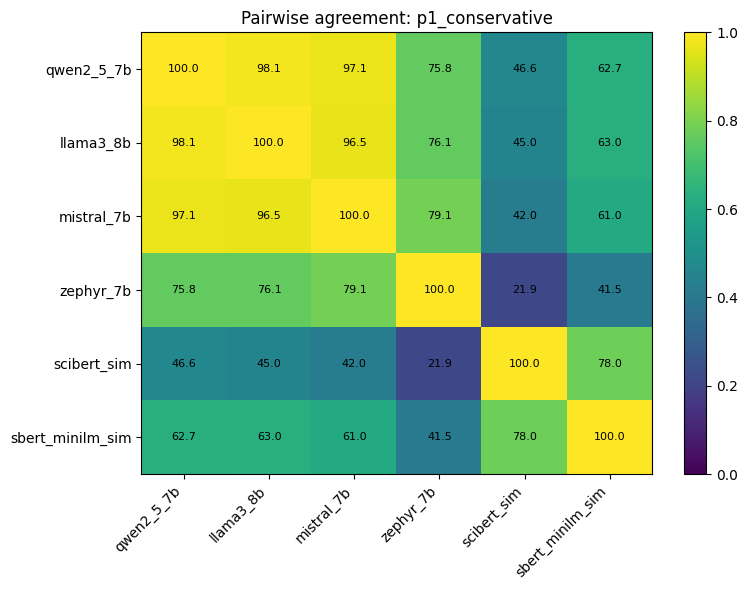

Saved heatmap: /content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/pairwise_agreement_heatmap_p1_conservative.png
Saved:
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/predictions_p1_conservative.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/raw_outputs_p1_conservative.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/results_p1_conservative.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/pairwise_agreement_percent_p1_conservative.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/pairwise_agreement_n_p1_conservative.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/pairwise_agreement_heatmap_p1_conservative.png


########################################################################################################################
RUNNING PROMPT: p2_balanced
##########################################

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

qwen2_5_7b-p2_balanced:   0%|          | 0/50 [00:00<?, ?it/s]


Result for qwen2_5_7b / p2_balanced


,model,prompt,type,runtime_s,items_per_sec,parse_rate,n_parsed,accuracy,precision,recall,f1,tp,tn,fp,fn
0,qwen2_5_7b,p2_balanced,LLM,32.364459,12.359236,0.9525,381,0.939633,0.994413,0.89,0.939314,178,180,1,22


...

,model,prompt,type,runtime_s,items_per_sec,parse_rate,n_parsed,accuracy,precision,recall,f1,tp,tn,fp,fn,error,threshold,calib_f1_all_eval
1,llama3_8b,p2_balanced,LLM,33.315484,12.006429,1.0000,400.0,0.950000,0.959184,0.940000,0.949495,188.0,192.0,8.0,12.0,NaN,NaN,NaN
2,mistral_7b,p2_balanced,LLM,41.298080,9.685680,1.0000,400.0,0.945000,0.978495,0.910000,0.943005,182.0,196.0,4.0,18.0,NaN,NaN,NaN
0,qwen2_5_7b,p2_balanced,LLM,32.364459,12.359236,0.9525,381.0,0.939633,0.994413,0.890000,0.939314,178.0,180.0,1.0,22.0,NaN,NaN,NaN
4,zephyr_7b,p2_balanced,LLM,147.261774,2.716251,0.9625,385.0,0.745455,1.000000,0.507538,0.673333,101.0,186.0,0.0,98.0,NaN,NaN,NaN
6,sbert_minilm_sim,p2_balanced,Encoder,0.133001,3007.488778,NaN,NaN,0.650000,0.596154,0.930000,0.726562,186.0,74.0,126.0,14.0,NaN,0.169268,0.726562
5,scibert_sim,p2_balanced,Encoder,0.837972,477.343096,NaN,NaN,0.505000,0.502525,0.995000,0.667785,199.0,3.0,197.0,1.0,NaN,0.419268,0.667785
3,phi3_5_mini,p2_balanced,LLM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AttributeError: 'DynamicCache' object has no a...,NaN,NaN



=== Pairwise agreement (%) for prompt: p2_balanced ===


,qwen2_5_7b,llama3_8b,mistral_7b,zephyr_7b,scibert_sim,sbert_minilm_sim
qwen2_5_7b,100.0,95.5,98.2,78.7,47.5,63.5
llama3_8b,95.5,100.0,96.5,75.3,49.5,63.5
mistral_7b,98.2,96.5,100.0,78.2,47.0,64.5
zephyr_7b,78.7,75.3,78.2,100.0,27.3,46.8
scibert_sim,47.5,49.5,47.0,27.3,100.0,78.0
sbert_minilm_sim,63.5,63.5,64.5,46.8,78.0,100.0



=== Pairwise compared-row counts for prompt: p2_balanced ===


,qwen2_5_7b,llama3_8b,mistral_7b,zephyr_7b,scibert_sim,sbert_minilm_sim
qwen2_5_7b,381.0,381.0,381.0,367.0,381.0,381.0
llama3_8b,381.0,400.0,400.0,385.0,400.0,400.0
mistral_7b,381.0,400.0,400.0,385.0,400.0,400.0
zephyr_7b,367.0,385.0,385.0,385.0,385.0,385.0
scibert_sim,381.0,400.0,400.0,385.0,400.0,400.0
sbert_minilm_sim,381.0,400.0,400.0,385.0,400.0,400.0


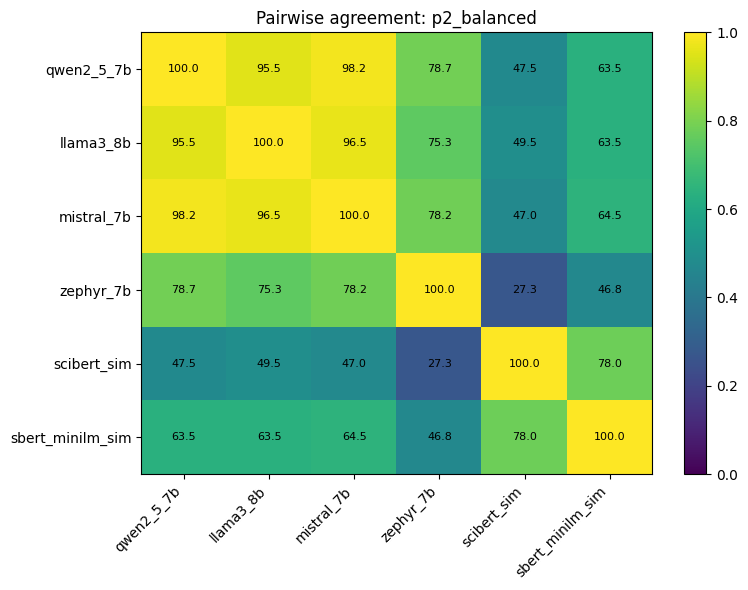

Saved heatmap: /content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/pairwise_agreement_heatmap_p2_balanced.png
Saved:
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/predictions_p2_balanced.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/raw_outputs_p2_balanced.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/results_p2_balanced.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/pairwise_agreement_percent_p2_balanced.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/pairwise_agreement_n_p2_balanced.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/pairwise_agreement_heatmap_p2_balanced.png


########################################################################################################################
RUNNING PROMPT: p3_evidence_cues
#################################################################

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

qwen2_5_7b-p3_evidence_cues:   0%|          | 0/50 [00:00<?, ?it/s]


Result for qwen2_5_7b / p3_evidence_cues


,model,prompt,type,runtime_s,items_per_sec,parse_rate,n_parsed,accuracy,precision,recall,f1,tp,tn,fp,fn
0,qwen2_5_7b,p3_evidence_cues,LLM,33.818031,11.82801,1.0,400,0.9425,0.994413,0.89,0.939314,178,199,1,22


...

,model,prompt,type,runtime_s,items_per_sec,parse_rate,n_parsed,accuracy,precision,recall,f1,tp,tn,fp,fn,error,threshold,calib_f1_all_eval
2,mistral_7b,p3_evidence_cues,LLM,43.602123,9.173865,1.00,400.0,0.952500,0.994536,0.910,0.950392,182.0,199.0,1.0,18.0,NaN,NaN,NaN
0,qwen2_5_7b,p3_evidence_cues,LLM,33.818031,11.828010,1.00,400.0,0.942500,0.994413,0.890,0.939314,178.0,199.0,1.0,22.0,NaN,NaN,NaN
1,llama3_8b,p3_evidence_cues,LLM,35.045887,11.413608,1.00,400.0,0.937500,0.931034,0.945,0.937965,189.0,186.0,14.0,11.0,NaN,NaN,NaN
4,zephyr_7b,p3_evidence_cues,LLM,144.570017,2.766825,0.97,388.0,0.726804,1.000000,0.470,0.639456,94.0,188.0,0.0,106.0,NaN,NaN,NaN
6,sbert_minilm_sim,p3_evidence_cues,Encoder,0.134444,2975.205932,NaN,NaN,0.650000,0.596154,0.930,0.726562,186.0,74.0,126.0,14.0,NaN,0.169268,0.726562
5,scibert_sim,p3_evidence_cues,Encoder,0.838349,477.128473,NaN,NaN,0.505000,0.502525,0.995,0.667785,199.0,3.0,197.0,1.0,NaN,0.419268,0.667785
3,phi3_5_mini,p3_evidence_cues,LLM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AttributeError: 'DynamicCache' object has no a...,NaN,NaN



=== Pairwise agreement (%) for prompt: p3_evidence_cues ===


,qwen2_5_7b,llama3_8b,mistral_7b,zephyr_7b,scibert_sim,sbert_minilm_sim
qwen2_5_7b,100.0,93.5,97.5,78.1,45.2,62.7
llama3_8b,93.5,100.0,93.5,72.2,51.2,62.3
mistral_7b,97.5,93.5,100.0,77.1,46.2,63.2
zephyr_7b,78.1,72.2,77.1,100.0,25.0,44.8
scibert_sim,45.2,51.2,46.2,25.0,100.0,78.0
sbert_minilm_sim,62.7,62.3,63.2,44.8,78.0,100.0



=== Pairwise compared-row counts for prompt: p3_evidence_cues ===


,qwen2_5_7b,llama3_8b,mistral_7b,zephyr_7b,scibert_sim,sbert_minilm_sim
qwen2_5_7b,400.0,400.0,400.0,388.0,400.0,400.0
llama3_8b,400.0,400.0,400.0,388.0,400.0,400.0
mistral_7b,400.0,400.0,400.0,388.0,400.0,400.0
zephyr_7b,388.0,388.0,388.0,388.0,388.0,388.0
scibert_sim,400.0,400.0,400.0,388.0,400.0,400.0
sbert_minilm_sim,400.0,400.0,400.0,388.0,400.0,400.0


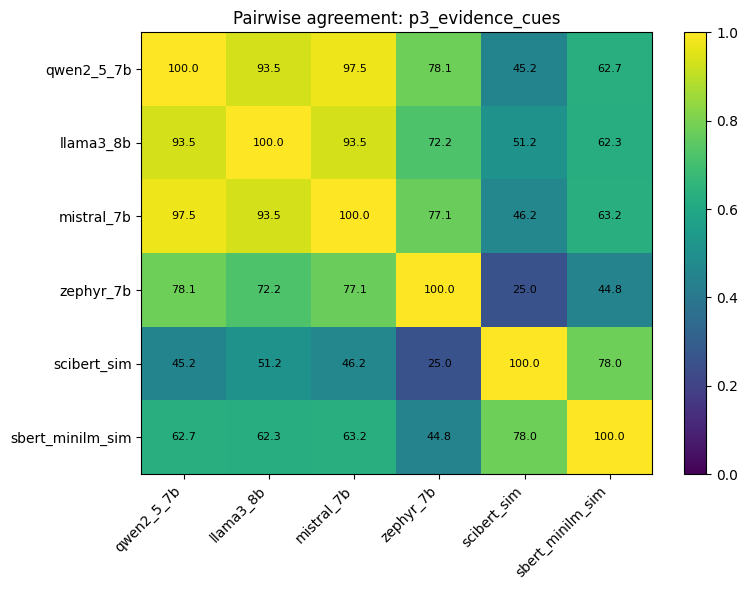

Saved heatmap: /content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/pairwise_agreement_heatmap_p3_evidence_cues.png
Saved:
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/predictions_p3_evidence_cues.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/raw_outputs_p3_evidence_cues.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/results_p3_evidence_cues.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/pairwise_agreement_percent_p3_evidence_cues.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/pairwise_agreement_n_p3_evidence_cues.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/pairwise_agreement_heatmap_p3_evidence_cues.png


########################################################################################################################
RUNNING PROMPT: p4_context_no_shot
############################

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

qwen2_5_7b-p4_context_no_shot:   0%|          | 0/50 [00:00<?, ?it/s]


Result for qwen2_5_7b / p4_context_no_shot


,model,prompt,type,runtime_s,items_per_sec,parse_rate,n_parsed,accuracy,precision,recall,f1,tp,tn,fp,fn
0,qwen2_5_7b,p4_context_no_shot,LLM,31.858758,12.555417,1.0,400,0.9425,1.0,0.885,0.938992,177,200,0,23


...

,model,prompt,type,runtime_s,items_per_sec,parse_rate,n_parsed,accuracy,precision,recall,f1,tp,tn,fp,fn,error,threshold,calib_f1_all_eval
0,qwen2_5_7b,p4_context_no_shot,LLM,31.858758,12.555417,1.0000,400.0,0.942500,1.000000,0.885,0.938992,177.0,200.0,0.0,23.0,NaN,NaN,NaN
1,llama3_8b,p4_context_no_shot,LLM,32.443465,12.329139,1.0000,400.0,0.942500,0.973262,0.910,0.940568,182.0,195.0,5.0,18.0,NaN,NaN,NaN
2,mistral_7b,p4_context_no_shot,LLM,40.392373,9.902860,1.0000,400.0,0.942500,0.988950,0.895,0.939633,179.0,198.0,2.0,21.0,NaN,NaN,NaN
4,zephyr_7b,p4_context_no_shot,LLM,145.555056,2.748101,0.9875,395.0,0.668354,1.000000,0.345,0.513011,69.0,195.0,0.0,131.0,NaN,NaN,NaN
6,sbert_minilm_sim,p4_context_no_shot,Encoder,0.138033,2897.854575,NaN,NaN,0.650000,0.596154,0.930,0.726562,186.0,74.0,126.0,14.0,NaN,0.169268,0.726562
5,scibert_sim,p4_context_no_shot,Encoder,0.839356,476.555867,NaN,NaN,0.505000,0.502525,0.995,0.667785,199.0,3.0,197.0,1.0,NaN,0.419268,0.667785
3,phi3_5_mini,p4_context_no_shot,LLM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AttributeError: 'DynamicCache' object has no a...,NaN,NaN



=== Pairwise agreement (%) for prompt: p4_context_no_shot ===


,qwen2_5_7b,llama3_8b,mistral_7b,zephyr_7b,scibert_sim,sbert_minilm_sim
qwen2_5_7b,100.0,96.5,98.0,72.7,44.8,62.7
llama3_8b,96.5,100.0,96.5,70.1,47.2,64.2
mistral_7b,98.0,96.5,100.0,71.6,45.8,63.2
zephyr_7b,72.7,70.1,71.6,100.0,18.5,38.5
scibert_sim,44.8,47.2,45.8,18.5,100.0,78.0
sbert_minilm_sim,62.7,64.2,63.2,38.5,78.0,100.0



=== Pairwise compared-row counts for prompt: p4_context_no_shot ===


,qwen2_5_7b,llama3_8b,mistral_7b,zephyr_7b,scibert_sim,sbert_minilm_sim
qwen2_5_7b,400.0,400.0,400.0,395.0,400.0,400.0
llama3_8b,400.0,400.0,400.0,395.0,400.0,400.0
mistral_7b,400.0,400.0,400.0,395.0,400.0,400.0
zephyr_7b,395.0,395.0,395.0,395.0,395.0,395.0
scibert_sim,400.0,400.0,400.0,395.0,400.0,400.0
sbert_minilm_sim,400.0,400.0,400.0,395.0,400.0,400.0


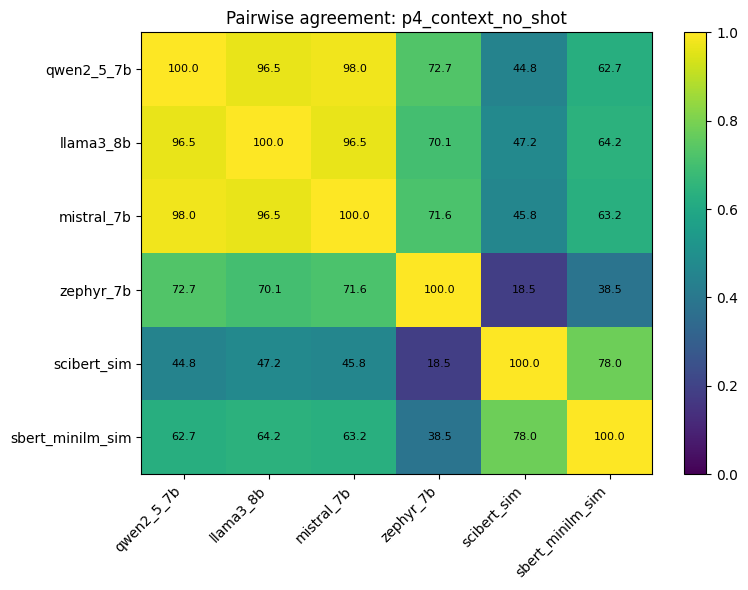

Saved heatmap: /content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/pairwise_agreement_heatmap_p4_context_no_shot.png
Saved:
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/predictions_p4_context_no_shot.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/raw_outputs_p4_context_no_shot.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/results_p4_context_no_shot.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/pairwise_agreement_percent_p4_context_no_shot.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/pairwise_agreement_n_p4_context_no_shot.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/pairwise_agreement_heatmap_p4_context_no_shot.png


########################################################################################################################
RUNNING PROMPT: p5_real_one_shot
################

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

qwen2_5_7b-p5_real_one_shot:   0%|          | 0/50 [00:00<?, ?it/s]


Result for qwen2_5_7b / p5_real_one_shot


,model,prompt,type,runtime_s,items_per_sec,parse_rate,n_parsed,accuracy,precision,recall,f1,tp,tn,fp,fn
0,qwen2_5_7b,p5_real_one_shot,LLM,42.352826,9.44447,1.0,400,0.9325,0.988701,0.875,0.928382,175,198,2,25


...

,model,prompt,type,runtime_s,items_per_sec,parse_rate,n_parsed,accuracy,precision,recall,f1,tp,tn,fp,fn,error,threshold,calib_f1_all_eval
2,mistral_7b,p5_real_one_shot,LLM,54.832951,7.294884,1.000,400.0,0.947500,0.968586,0.925000,0.946292,185.0,194.0,6.0,15.0,NaN,NaN,NaN
0,qwen2_5_7b,p5_real_one_shot,LLM,42.352826,9.444470,1.000,400.0,0.932500,0.988701,0.875000,0.928382,175.0,198.0,2.0,25.0,NaN,NaN,NaN
1,llama3_8b,p5_real_one_shot,LLM,44.916040,8.905505,1.000,400.0,0.930000,0.934343,0.925000,0.929648,185.0,187.0,13.0,15.0,NaN,NaN,NaN
4,zephyr_7b,p5_real_one_shot,LLM,174.907197,2.286927,0.915,366.0,0.825137,1.000000,0.654054,0.790850,121.0,181.0,0.0,64.0,NaN,NaN,NaN
6,sbert_minilm_sim,p5_real_one_shot,Encoder,0.135178,2959.059434,NaN,NaN,0.650000,0.596154,0.930000,0.726562,186.0,74.0,126.0,14.0,NaN,0.169268,0.726562
5,scibert_sim,p5_real_one_shot,Encoder,0.848558,471.387694,NaN,NaN,0.505000,0.502525,0.995000,0.667785,199.0,3.0,197.0,1.0,NaN,0.419268,0.667785
3,phi3_5_mini,p5_real_one_shot,LLM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AttributeError: 'DynamicCache' object has no a...,NaN,NaN



=== Pairwise agreement (%) for prompt: p5_real_one_shot ===


,qwen2_5_7b,llama3_8b,mistral_7b,zephyr_7b,scibert_sim,sbert_minilm_sim
qwen2_5_7b,100.0,94.2,95.5,88.0,44.8,62.7
llama3_8b,94.2,100.0,94.8,83.9,50.0,66.0
mistral_7b,95.5,94.8,100.0,84.7,47.8,64.2
zephyr_7b,88.0,83.9,84.7,100.0,33.9,51.9
scibert_sim,44.8,50.0,47.8,33.9,100.0,78.0
sbert_minilm_sim,62.7,66.0,64.2,51.9,78.0,100.0



=== Pairwise compared-row counts for prompt: p5_real_one_shot ===


,qwen2_5_7b,llama3_8b,mistral_7b,zephyr_7b,scibert_sim,sbert_minilm_sim
qwen2_5_7b,400.0,400.0,400.0,366.0,400.0,400.0
llama3_8b,400.0,400.0,400.0,366.0,400.0,400.0
mistral_7b,400.0,400.0,400.0,366.0,400.0,400.0
zephyr_7b,366.0,366.0,366.0,366.0,366.0,366.0
scibert_sim,400.0,400.0,400.0,366.0,400.0,400.0
sbert_minilm_sim,400.0,400.0,400.0,366.0,400.0,400.0


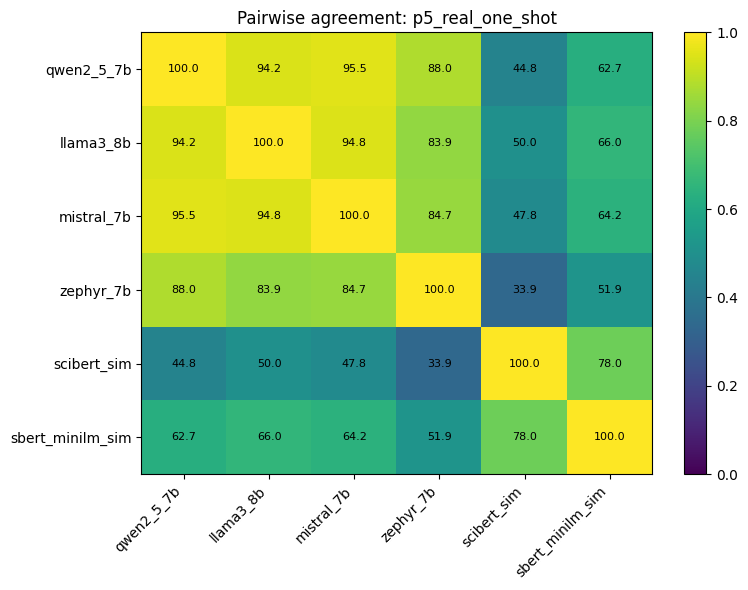

Saved heatmap: /content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/pairwise_agreement_heatmap_p5_real_one_shot.png
Saved:
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/predictions_p5_real_one_shot.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/raw_outputs_p5_real_one_shot.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/results_p5_real_one_shot.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/pairwise_agreement_percent_p5_real_one_shot.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/pairwise_agreement_n_p5_real_one_shot.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/pairwise_agreement_heatmap_p5_real_one_shot.png


########################################################################################################################
RUNNING PROMPT: p6_real_five_shot
#############################

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

qwen2_5_7b-p6_real_five_shot:   0%|          | 0/50 [00:00<?, ?it/s]


Result for qwen2_5_7b / p6_real_five_shot


,model,prompt,type,runtime_s,items_per_sec,parse_rate,n_parsed,accuracy,precision,recall,f1,tp,tn,fp,fn
0,qwen2_5_7b,p6_real_five_shot,LLM,73.511608,5.441318,1.0,400,0.9325,1.0,0.865,0.927614,173,200,0,27


...

,model,prompt,type,runtime_s,items_per_sec,parse_rate,n_parsed,accuracy,precision,recall,f1,tp,tn,fp,fn,error,threshold,calib_f1_all_eval
2,mistral_7b,p6_real_five_shot,LLM,99.266788,4.029545,1.000,400.0,0.945000,0.949495,0.940000,0.944724,188.0,190.0,10.0,12.0,NaN,NaN,NaN
1,llama3_8b,p6_real_five_shot,LLM,77.733905,5.145760,1.000,400.0,0.935000,0.994318,0.875000,0.930851,175.0,199.0,1.0,25.0,NaN,NaN,NaN
0,qwen2_5_7b,p6_real_five_shot,LLM,73.511608,5.441318,1.000,400.0,0.932500,1.000000,0.865000,0.927614,173.0,200.0,0.0,27.0,NaN,NaN,NaN
4,zephyr_7b,p6_real_five_shot,LLM,255.332869,1.566582,0.935,374.0,0.802139,0.975610,0.628272,0.764331,120.0,180.0,3.0,71.0,NaN,NaN,NaN
6,sbert_minilm_sim,p6_real_five_shot,Encoder,0.135939,2942.498803,NaN,NaN,0.650000,0.596154,0.930000,0.726562,186.0,74.0,126.0,14.0,NaN,0.169268,0.726562
5,scibert_sim,p6_real_five_shot,Encoder,0.836340,478.274142,NaN,NaN,0.505000,0.502525,0.995000,0.667785,199.0,3.0,197.0,1.0,NaN,0.419268,0.667785
3,phi3_5_mini,p6_real_five_shot,LLM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AttributeError: 'DynamicCache' object has no a...,NaN,NaN



=== Pairwise agreement (%) for prompt: p6_real_five_shot ===


,qwen2_5_7b,llama3_8b,mistral_7b,zephyr_7b,scibert_sim,sbert_minilm_sim
qwen2_5_7b,100.0,98.8,93.8,85.8,43.8,62.3
llama3_8b,98.8,100.0,94.0,85.8,44.5,63.0
mistral_7b,93.8,94.0,100.0,81.0,50.0,65.0
zephyr_7b,85.8,85.8,81.0,100.0,33.7,51.1
scibert_sim,43.8,44.5,50.0,33.7,100.0,78.0
sbert_minilm_sim,62.3,63.0,65.0,51.1,78.0,100.0



=== Pairwise compared-row counts for prompt: p6_real_five_shot ===


,qwen2_5_7b,llama3_8b,mistral_7b,zephyr_7b,scibert_sim,sbert_minilm_sim
qwen2_5_7b,400.0,400.0,400.0,374.0,400.0,400.0
llama3_8b,400.0,400.0,400.0,374.0,400.0,400.0
mistral_7b,400.0,400.0,400.0,374.0,400.0,400.0
zephyr_7b,374.0,374.0,374.0,374.0,374.0,374.0
scibert_sim,400.0,400.0,400.0,374.0,400.0,400.0
sbert_minilm_sim,400.0,400.0,400.0,374.0,400.0,400.0


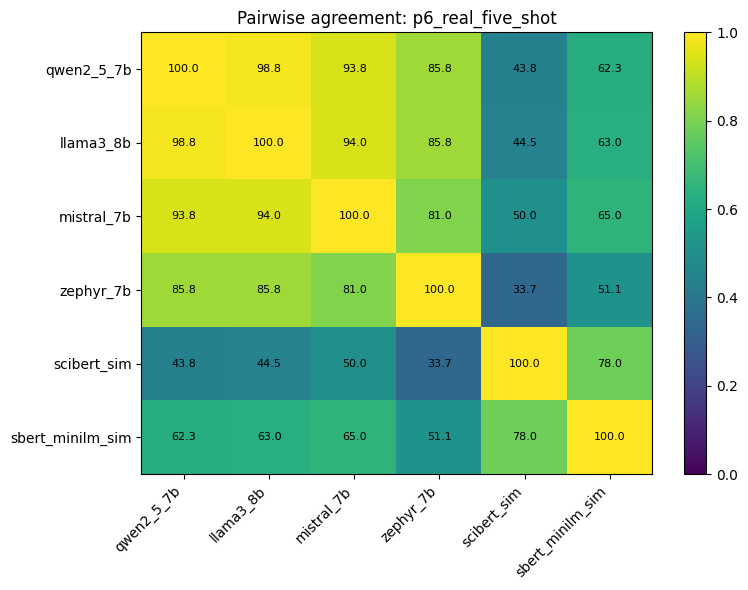

Saved heatmap: /content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/pairwise_agreement_heatmap_p6_real_five_shot.png
Saved:
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/predictions_p6_real_five_shot.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/raw_outputs_p6_real_five_shot.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/results_p6_real_five_shot.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/pairwise_agreement_percent_p6_real_five_shot.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/pairwise_agreement_n_p6_real_five_shot.csv
/content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/pairwise_agreement_heatmap_p6_real_five_shot.png

Saved combined results: /content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/ALL_prompt_model_results_summary.csv

=== FINAL ORDERED RESULTS: highest accuracy

,prompt,model,type,accuracy,precision,recall,f1,tp,tn,fp,fn,parse_rate,items_per_sec,runtime_s,error
0,p3_evidence_cues,mistral_7b,LLM,0.952500,0.994536,0.910000,0.950392,182.0,199.0,1.0,18.0,1.0000,9.173865,43.602123,NaN
1,p2_balanced,llama3_8b,LLM,0.950000,0.959184,0.940000,0.949495,188.0,192.0,8.0,12.0,1.0000,12.006429,33.315484,NaN
2,p5_real_one_shot,mistral_7b,LLM,0.947500,0.968586,0.925000,0.946292,185.0,194.0,6.0,15.0,1.0000,7.294884,54.832951,NaN
3,p6_real_five_shot,mistral_7b,LLM,0.945000,0.949495,0.940000,0.944724,188.0,190.0,10.0,12.0,1.0000,4.029545,99.266788,NaN
4,p2_balanced,mistral_7b,LLM,0.945000,0.978495,0.910000,0.943005,182.0,196.0,4.0,18.0,1.0000,9.685680,41.298080,NaN
5,p4_context_no_shot,llama3_8b,LLM,0.942500,0.973262,0.910000,0.940568,182.0,195.0,5.0,18.0,1.0000,12.329139,32.443465,NaN
6,p4_context_no_shot,mistral_7b,LLM,0.942500,0.988950,0.895000,0.939633,179.0,198.0,2.0,21.0,1.0000,9.902860,40.392373,NaN
7,p3_evidence_cues,qwen2_5_7b,LLM,0.942500,0.994413,0.890000,0.939314,178.0,199.0,1.0,22.0,1.0000,11.828010,33.818031,NaN
8,p4_context_no_shot,qwen2_5_7b,LLM,0.942500,1.000000,0.885000,0.938992,177.0,200.0,0.0,23.0,1.0000,12.555417,31.858758,NaN
9,p2_balanced,qwen2_5_7b,LLM,0.939633,0.994413,0.890000,0.939314,178.0,180.0,1.0,22.0,0.9525,12.359236,32.364459,NaN


Saved ranked results: /content/drive/MyDrive/backup/Downloads/0_UKB/ukb_prompt_eval_outputs_v2/ALL_prompt_model_results_ranked_by_accuracy.csv

=== LLM-only ranking ===


,prompt,model,type,accuracy,precision,recall,f1,tp,tn,fp,fn,parse_rate,items_per_sec,runtime_s,error
0,p3_evidence_cues,mistral_7b,LLM,0.952500,0.994536,0.910000,0.950392,182.0,199.0,1.0,18.0,1.0000,9.173865,43.602123,NaN
1,p2_balanced,llama3_8b,LLM,0.950000,0.959184,0.940000,0.949495,188.0,192.0,8.0,12.0,1.0000,12.006429,33.315484,NaN
2,p5_real_one_shot,mistral_7b,LLM,0.947500,0.968586,0.925000,0.946292,185.0,194.0,6.0,15.0,1.0000,7.294884,54.832951,NaN
3,p6_real_five_shot,mistral_7b,LLM,0.945000,0.949495,0.940000,0.944724,188.0,190.0,10.0,12.0,1.0000,4.029545,99.266788,NaN
4,p2_balanced,mistral_7b,LLM,0.945000,0.978495,0.910000,0.943005,182.0,196.0,4.0,18.0,1.0000,9.685680,41.298080,NaN
5,p4_context_no_shot,llama3_8b,LLM,0.942500,0.973262,0.910000,0.940568,182.0,195.0,5.0,18.0,1.0000,12.329139,32.443465,NaN
6,p4_context_no_shot,mistral_7b,LLM,0.942500,0.988950,0.895000,0.939633,179.0,198.0,2.0,21.0,1.0000,9.902860,40.392373,NaN
7,p3_evidence_cues,qwen2_5_7b,LLM,0.942500,0.994413,0.890000,0.939314,178.0,199.0,1.0,22.0,1.0000,11.828010,33.818031,NaN
8,p4_context_no_shot,qwen2_5_7b,LLM,0.942500,1.000000,0.885000,0.938992,177.0,200.0,0.0,23.0,1.0000,12.555417,31.858758,NaN
9,p2_balanced,qwen2_5_7b,LLM,0.939633,0.994413,0.890000,0.939314,178.0,180.0,1.0,22.0,0.9525,12.359236,32.364459,NaN


In [ ]:


# ============================================================
# Data loading
# ============================================================

def extract_text(x):
    if pd.isna(x):
        return ""
    if not isinstance(x, str):
        return str(x).strip()
    s = x.strip()
    if s.startswith("{") and s.endswith("}"):
        try:
            obj = ast.literal_eval(s)
            if isinstance(obj, dict):
                if "preferred" in obj and obj["preferred"] is not None:
                    return str(obj["preferred"]).strip()
                for v in obj.values():
                    if v is not None and str(v).strip():
                        return str(v).strip()
        except Exception:
            pass
    return s

def load_labelled_csv(path, expected_label):
    df = pd.read_csv(path)

    for c in ["id", "title", "abstract", "year"]:
        if c not in df.columns:
            raise ValueError(f"Missing column {c} in {path}. Columns: {df.columns.tolist()}")

    out = df[["id", "title", "abstract", "year"]].copy()
    out["id"] = out["id"].astype(str).str.strip()
    out["title"] = out["title"].apply(extract_text)
    out["abstract"] = out["abstract"].apply(extract_text)
    out["year"] = pd.to_numeric(out["year"], errors="coerce")
    out["label"] = int(expected_label)

    out = out[out["id"].ne("")]
    out = out[out["abstract"].fillna("").astype(str).str.strip().ne("")]
    out = out.drop_duplicates(subset=["id"], keep="first").reset_index(drop=True)
    return out

tp_pool = load_labelled_csv(TP_PATH, 1)
tn_pool = load_labelled_csv(TN_PATH, 0)

print("TP pool:", len(tp_pool), "unique ids:", tp_pool["id"].nunique())
print("TN pool:", len(tn_pool), "unique ids:", tn_pool["id"].nunique())

assert len(tp_pool) >= N_POS, f"Not enough positives: {len(tp_pool)}"
assert len(tn_pool) >= N_NEG, f"Not enough negatives: {len(tn_pool)}"

tp_eval = tp_pool.sample(n=N_POS, random_state=SEED).copy()
tn_eval = tn_pool.sample(n=N_NEG, random_state=SEED).copy()

eval_df = pd.concat([tp_eval, tn_eval], ignore_index=True)
eval_df = eval_df.sample(frac=1, random_state=SEED).reset_index(drop=True)
eval_df["True_label"] = eval_df["label"].astype(bool)

eval_path = os.path.join(OUT_DIR, "ukb_eval_200pos_200neg.csv")
eval_df.to_csv(eval_path, index=False)

print("Eval set:", eval_df.shape)
print(eval_df["label"].value_counts())
print("Saved eval set:", eval_path)
display(eval_df.head(10))

# ============================================================
# Few-shot example selection
# ============================================================

def contains_ukb_text(row):
    text = f"{row.get('title','')} {row.get('abstract','')}".lower()
    return any(x in text for x in [
        "uk biobank", "ukb", "ukbb", "united kingdom biobank", "uk biobank resource"
    ])

def contains_hard_negative_cue(row):
    text = f"{row.get('title','')} {row.get('abstract','')}".lower()
    cues = [
        "unlike uk biobank", "compared with uk biobank", "such as uk biobank",
        "including uk biobank", "biobanks such as", "ethical", "governance",
        "china kadoorie", "biobank japan", "finnish biobank", "fingen", "finngen",
        "all of us", "janus serum bank", "copenhagen hospital biobank"
    ]
    return any(c in text for c in cues)

eval_ids = set(eval_df["id"].astype(str))
tp_demo_pool = tp_pool[~tp_pool["id"].astype(str).isin(eval_ids)].copy()
tn_demo_pool = tn_pool[~tn_pool["id"].astype(str).isin(eval_ids)].copy()

# Prefer one positive without explicit UKB text if available, because this is the hard recall case.
tp_no_ukb = tp_demo_pool[~tp_demo_pool.apply(contains_ukb_text, axis=1)]
tp_with_ukb = tp_demo_pool[tp_demo_pool.apply(contains_ukb_text, axis=1)]
tn_hard = tn_demo_pool[tn_demo_pool.apply(contains_hard_negative_cue, axis=1)]

one_pos = (tp_no_ukb if len(tp_no_ukb) > 0 else tp_demo_pool).sample(n=1, random_state=SEED + 1)
one_neg = (tn_hard if len(tn_hard) > 0 else tn_demo_pool).sample(n=1, random_state=SEED + 2)

# Five-shot: 3 positives + 2 negatives.
tp_demo_1 = (tp_no_ukb if len(tp_no_ukb) >= 1 else tp_demo_pool).sample(n=1, random_state=SEED + 3)
tp_demo_2 = (tp_with_ukb if len(tp_with_ukb) >= 2 else tp_demo_pool).sample(n=2, random_state=SEED + 4)
tn_demo_1 = (tn_hard if len(tn_hard) >= 1 else tn_demo_pool).sample(n=1, random_state=SEED + 5)
tn_demo_2 = tn_demo_pool.sample(n=1, random_state=SEED + 6)

fewshot_examples = []
for _, r in pd.concat([tp_demo_1, tp_demo_2]).iterrows():
    fewshot_examples.append({"title": r["title"], "abstract": r["abstract"], "label": True})
for _, r in pd.concat([tn_demo_1, tn_demo_2]).iterrows():
    fewshot_examples.append({"title": r["title"], "abstract": r["abstract"], "label": False})

random.Random(SEED).shuffle(fewshot_examples)

print("\nOne-shot positive example:")
display(one_pos[["id", "title", "abstract", "label"]].head(1))

print("\nOne-shot negative example:")
display(one_neg[["id", "title", "abstract", "label"]].head(1))

print("\nFew-shot examples:")
for ex in fewshot_examples:
    print(ex["label"], ex["title"][:120])

# ============================================================
# Prompts
# ============================================================

def truncate_text(s, max_chars=3500):
    s = str(s or "")
    return s[:max_chars]

def json_instruction():
    return """Return strict JSON only:
{"implies_UKB_use":true|false}
Do not include explanation, markdown, or any extra keys."""

def make_prompt_v1_conservative(title, abstract):
    return f"""You will be given a scientific paper title and abstract.

Task: decide whether the paper used UK Biobank data or resources.

Definition:
- true: the study used UK Biobank data, participants, samples, imaging, genetics, linked health records, or another UK Biobank resource.
- false: the paper only mentions UK Biobank, discusses biobanks generally, compares with UK Biobank, or uses other biobanks but not UK Biobank.

Be conservative. If uncertain, return false.

{json_instruction()}

title: \"\"\"{truncate_text(title, 700)}\"\"\"

abstract: \"\"\"{truncate_text(abstract, 3200)}\"\"\"

JSON:
"""

def make_prompt_v2_balanced(title, abstract):
    return f"""You will be given a scientific paper title and abstract.

Task: decide whether the paper likely used UK Biobank data or resources.

Important:
- Some true UK Biobank-use papers do not mention "UK Biobank" in the abstract.
- The paper may still use UK Biobank if the abstract describes a UK population-scale cohort, genetic/imaging/health-record analysis, or data-resource use that is consistent with UK Biobank.
- Do not require explicit words "UK Biobank" if the evidence strongly suggests use.

Return true when the title/abstract provides reasonable evidence that the paper analysed UK Biobank participants, data, samples, imaging, genetics, linked records, or a UK Biobank-derived cohort.

Return false when the paper is only about generic biobanking, ethics/governance, reviews, comparisons, or another named biobank.

{json_instruction()}

title: \"\"\"{truncate_text(title, 700)}\"\"\"

abstract: \"\"\"{truncate_text(abstract, 3200)}\"\"\"

JSON:
"""

def make_prompt_v3_evidence_cues(title, abstract):
    return f"""Classify whether this paper uses UK Biobank.

Use the following cues.

Positive evidence can include:
- explicit UK Biobank / UKB / UKBB mention;
- analysis of a very large UK cohort with genetic, imaging, health-record, lifestyle, biomarker, or hospital-linked data;
- phrases such as participants, cohort, baseline assessment, imaging assessment, genotyping, exome sequencing, linked health records, Hospital Episode Statistics, or Townsend deprivation index in a UK population context;
- a study design that clearly analyses participant-level data rather than merely discussing biobanks.

Negative evidence can include:
- generic discussion of biobanks;
- ethics, governance, consent, infrastructure, sample storage, or review articles;
- use of another biobank only;
- mentions like "such as UK Biobank", "unlike UK Biobank", or comparison with UK Biobank.

Prefer true if the abstract strongly looks like an original analysis using UK Biobank-style data, even if UK Biobank is not named in the abstract.
Prefer false if the abstract is generic or only about other biobanks.

{json_instruction()}

title: \"\"\"{truncate_text(title, 700)}\"\"\"

abstract: \"\"\"{truncate_text(abstract, 3200)}\"\"\"

JSON:
"""

def make_prompt_v4_context_no_shot(title, abstract):
    return f"""You will classify a paper using only its title and abstract.

Context:
All papers in this evaluation were retrieved because their full text matched at least one UK Biobank-related query. Therefore, UK Biobank may be mentioned only outside the abstract.

Question:
Based on the title and abstract, is it likely that the paper used UK Biobank data/resources in its own analysis?

Label true if likely UK Biobank use.
Label false if the paper likely only mentions UK Biobank, discusses biobanks generally, or uses other non-UKB resources.

Do not be overly strict: if the paper is an original epidemiological, genetic, imaging, biomarker, or clinical-risk study and the abstract strongly suggests use of a UK population-scale linked cohort, return true.

{json_instruction()}

title: \"\"\"{truncate_text(title, 700)}\"\"\"

abstract: \"\"\"{truncate_text(abstract, 3200)}\"\"\"

JSON:
"""

def make_prompt_v5_one_shot(title, abstract):
    pos = one_pos.iloc[0]
    neg = one_neg.iloc[0]

    return f"""You will be given a scientific paper title and abstract.

Task:
Decide whether the paper likely used UK Biobank data/resources in its own analysis.

Context:
All papers in this evaluation were retrieved because their full text matched a UK Biobank-related search. Some true positives may not mention UK Biobank in the abstract.

{json_instruction()}

Example positive:
title: \"\"\"{truncate_text(pos["title"], 500)}\"\"\"
abstract: \"\"\"{truncate_text(pos["abstract"], 1800)}\"\"\"
answer: {{"implies_UKB_use":true}}

Example negative:
title: \"\"\"{truncate_text(neg["title"], 500)}\"\"\"
abstract: \"\"\"{truncate_text(neg["abstract"], 1800)}\"\"\"
answer: {{"implies_UKB_use":false}}

Now classify this paper.

title: \"\"\"{truncate_text(title, 700)}\"\"\"

abstract: \"\"\"{truncate_text(abstract, 3200)}\"\"\"

JSON:
"""

def make_prompt_v6_five_shot(title, abstract):
    examples_txt = []
    for i, ex in enumerate(fewshot_examples, start=1):
        examples_txt.append(
            f"""Example {i}
title: \"\"\"{truncate_text(ex["title"], 450)}\"\"\"
abstract: \"\"\"{truncate_text(ex["abstract"], 1300)}\"\"\"
answer: {{"implies_UKB_use":{str(ex["label"]).lower()}}}
"""
        )

    examples_block = "\n".join(examples_txt)

    return f"""You will be given a scientific paper title and abstract.

Task:
Decide whether the paper likely used UK Biobank data/resources in its own analysis.

Context:
All papers in this evaluation were retrieved because their full text matched a UK Biobank-related search.
Some true UK Biobank-use papers may not mention UK Biobank in the abstract.
Some false positives mention biobanks, UK cohorts, or other biobanks but do not use UK Biobank.

Return true when the paper likely analysed UK Biobank participants, data, samples, imaging, genetics, linked health records, or other UK Biobank resources.
Return false for generic biobank discussion, ethics/governance, reviews, comparisons, or other-biobank-only papers.

{json_instruction()}

Few-shot examples:
{examples_block}

Now classify this paper.

title: \"\"\"{truncate_text(title, 700)}\"\"\"

abstract: \"\"\"{truncate_text(abstract, 3200)}\"\"\"

JSON:
"""

PROMPT_BUILDERS = {
    "p1_conservative": make_prompt_v1_conservative,
    "p2_balanced": make_prompt_v2_balanced,
    "p3_evidence_cues": make_prompt_v3_evidence_cues,
    "p4_context_no_shot": make_prompt_v4_context_no_shot,
    "p5_real_one_shot": make_prompt_v5_one_shot,
    "p6_real_five_shot": make_prompt_v6_five_shot,
}

# ============================================================
# Parsing and metrics
# ============================================================

def extract_first_json_obj(text):
    raw = (text or "").strip()
    raw = re.sub(r"^```(?:json)?\s*|\s*```$", "", raw, flags=re.I | re.S).strip()
    try:
        return json.loads(raw)
    except Exception:
        pass

    m = re.search(r"\{.*?\}", raw, flags=re.S)
    if m:
        try:
            return json.loads(m.group(0))
        except Exception:
            pass
    return None

def parse_llm_result(obj):
    if not isinstance(obj, dict):
        return None

    val = obj.get("implies_UKB_use", None)

    if isinstance(val, bool):
        return val

    if isinstance(val, str):
        v = val.strip().lower()
        if v in {"true", "yes", "1"}:
            return True
        if v in {"false", "no", "0"}:
            return False

    return None

def build_model_input(tokenizer, user_text):
    if hasattr(tokenizer, "apply_chat_template") and tokenizer.chat_template:
        msgs = [{"role": "user", "content": user_text}]
        try:
            return tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        except Exception:
            return user_text
    return user_text

def metric_dict(y_true, y_pred):
    y_true = np.asarray(y_true).astype(bool)
    y_pred = np.asarray(y_pred).astype(bool)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[False, True]).ravel()
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn),
    }

def pairwise_agreement_matrix(pred_df, model_cols):
    agree = pd.DataFrame(index=model_cols, columns=model_cols, dtype=float)
    nmat = pd.DataFrame(index=model_cols, columns=model_cols, dtype=int)

    for a in model_cols:
        for b in model_cols:
            m = pred_df[[a, b]].dropna()
            n = len(m)
            nmat.loc[a, b] = n
            agree.loc[a, b] = (m[a].astype(bool).values == m[b].astype(bool).values).mean() if n else np.nan

    return agree, nmat

def save_agreement_heatmap(agreement, prompt_name, out_dir):
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(agreement.values.astype(float), vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(agreement.columns)))
    ax.set_yticks(range(len(agreement.index)))
    ax.set_xticklabels(agreement.columns, rotation=45, ha="right")
    ax.set_yticklabels(agreement.index)
    ax.set_title(f"Pairwise agreement: {prompt_name}")

    for i in range(len(agreement.index)):
        for j in range(len(agreement.columns)):
            val = agreement.iloc[i, j]
            if pd.notna(val):
                ax.text(j, i, f"{val*100:.1f}", ha="center", va="center", fontsize=8)

    fig.colorbar(im, ax=ax)
    plt.tight_layout()

    path = os.path.join(out_dir, f"pairwise_agreement_heatmap_{prompt_name}.png")
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved heatmap:", path)
    return path

# ============================================================
# LLM loading and prediction
# ============================================================

def load_llm(model_id, tag):
    token = os.getenv("HF_TOKEN", None)

    tokenizer = AutoTokenizer.from_pretrained(
        model_id,
        use_fast=True,
        token=token,
        trust_remote_code=True,
    )

    tokenizer.padding_side = "left"
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token

    quant_config = None
    dtype = torch.float16

    if USE_4BIT and torch.cuda.is_available():
        quant_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.float16,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4",
        )

    kwargs = dict(
        device_map="auto",
        torch_dtype=dtype,
        token=token,
        trust_remote_code=True,
    )

    if quant_config is not None:
        kwargs["quantization_config"] = quant_config

    # Phi-specific fix: use Phi-3.5 and eager attention.
    # This avoids the common Phi-3 rope/config/flash-attention loading issue.
    if "phi" in tag.lower():
        kwargs["attn_implementation"] = "eager"

    model = AutoModelForCausalLM.from_pretrained(model_id, **kwargs).eval()

    return tokenizer, model

def run_llm_for_prompt(model_id, tag, prompt_name, prompt_fn, df, batch_size=8, max_input_tokens=4096, max_new_tokens=64):
    print("\n" + "=" * 100)
    print(f"LLM: {tag} | Prompt: {prompt_name}")
    print(f"Model: {model_id}")
    print("=" * 100)

    tokenizer, model = load_llm(model_id, tag)

    n = len(df)
    preds = np.full(n, np.nan, dtype=object)
    raw_outputs = [""] * n
    parse_ok = np.zeros(n, dtype=bool)

    t0 = time.time()

    for s in tqdm(range(0, n, batch_size), desc=f"{tag}-{prompt_name}"):
        e = min(s + batch_size, n)
        batch = df.iloc[s:e]

        prompts = [
            build_model_input(tokenizer, prompt_fn(r["title"], r["abstract"]))
            for _, r in batch.iterrows()
        ]

        inputs = tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_input_tokens,
        ).to(model.device)

        with torch.inference_mode():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

        prompt_len = inputs["input_ids"].shape[1]
        gen_only = output_ids[:, prompt_len:]
        texts = tokenizer.batch_decode(gen_only, skip_special_tokens=True)

        for i, txt in enumerate(texts):
            idx = s + i
            raw_outputs[idx] = txt
            obj = extract_first_json_obj(txt)
            val_out = parse_llm_result(obj)

            if val_out is not None:
                preds[idx] = bool(val_out)
                parse_ok[idx] = True

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    runtime = time.time() - t0

    del model, tokenizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return preds, raw_outputs, {
        "model": tag,
        "prompt": prompt_name,
        "type": "LLM",
        "runtime_s": runtime,
        "items_per_sec": n / max(runtime, 1e-9),
        "parse_rate": parse_ok.mean(),
        "n_parsed": int(parse_ok.sum()),
    }

# ============================================================
# Encoder baselines
# ============================================================

def mean_pool(last_hidden, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
    return (last_hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)

def best_threshold(scores, labels):
    labels = np.asarray(labels).astype(bool)
    scores = np.asarray(scores)
    thresholds = np.linspace(scores.min(), scores.max(), 200)

    best_f1 = -1
    best_t = None

    for t in thresholds:
        pred = scores >= t
        f1 = f1_score(labels, pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    return float(best_t), float(best_f1)

def run_scibert_baseline(df):
    tag = "scibert_sim"
    model_id = "allenai/scibert_scivocab_uncased"
    device = "cuda" if torch.cuda.is_available() else "cpu"

    print("\n" + "=" * 100)
    print("Encoder baseline:", tag)
    print("=" * 100)

    tok = AutoTokenizer.from_pretrained(model_id, use_fast=True)
    model = AutoModel.from_pretrained(model_id).to(device).eval()

    query = "This scientific paper uses UK Biobank data or resources."
    q = tok([query], return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)

    with torch.inference_mode():
        qout = model(**q)
        qemb = mean_pool(qout.last_hidden_state, q["attention_mask"])
        qemb = torch.nn.functional.normalize(qemb, dim=1)

    scores = np.zeros(len(df))
    texts = (df["title"].fillna("") + "\n" + df["abstract"].fillna("")).tolist()

    t0 = time.time()
    batch_size = 64

    for s in tqdm(range(0, len(texts), batch_size), desc=tag):
        e = min(s + batch_size, len(texts))
        inp = tok(texts[s:e], return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)

        with torch.inference_mode():
            out = model(**inp)
            emb = mean_pool(out.last_hidden_state, inp["attention_mask"])
            emb = torch.nn.functional.normalize(emb, dim=1)
            scores[s:e] = (emb @ qemb.T).squeeze(1).detach().cpu().numpy()

    runtime = time.time() - t0

    del model, tok
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    thr, calib_f1 = best_threshold(scores, df["True_label"].values)
    preds = scores >= thr

    meta = {
        "model": tag,
        "prompt": "encoder_similarity",
        "type": "Encoder",
        "runtime_s": runtime,
        "items_per_sec": len(df) / max(runtime, 1e-9),
        "threshold": thr,
        "calib_f1_all_eval": calib_f1,
    }

    return preds, scores, meta

def run_sbert_baseline(df):
    tag = "sbert_minilm_sim"
    model_id = "sentence-transformers/all-MiniLM-L6-v2"
    device = "cuda" if torch.cuda.is_available() else "cpu"

    print("\n" + "=" * 100)
    print("Encoder baseline:", tag)
    print("=" * 100)

    model = SentenceTransformer(model_id, device=device)

    query = "This scientific paper uses UK Biobank data or resources."
    q_emb = model.encode([query], normalize_embeddings=True)

    texts = (df["title"].fillna("") + "\n" + df["abstract"].fillna("")).tolist()

    t0 = time.time()
    emb = model.encode(texts, normalize_embeddings=True, batch_size=128, show_progress_bar=True)
    runtime = time.time() - t0

    scores = emb @ q_emb[0]

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    thr, calib_f1 = best_threshold(scores, df["True_label"].values)
    preds = scores >= thr

    meta = {
        "model": tag,
        "prompt": "encoder_similarity",
        "type": "Encoder",
        "runtime_s": runtime,
        "items_per_sec": len(df) / max(runtime, 1e-9),
        "threshold": thr,
        "calib_f1_all_eval": calib_f1,
    }

    return preds, scores, meta

# ============================================================
# Models
# ============================================================

LLM_SPECS = [
    ("Qwen/Qwen2.5-7B-Instruct", "qwen2_5_7b", 8),
    ("meta-llama/Meta-Llama-3-8B-Instruct", "llama3_8b", 8),
    ("mistralai/Mistral-7B-Instruct-v0.3", "mistral_7b", 8),
    ("microsoft/Phi-3.5-mini-instruct", "phi3_5_mini", 16),
    ("HuggingFaceH4/zephyr-7b-beta", "zephyr_7b", 8),
]

if not os.getenv("HF_TOKEN", "").strip():
    LLM_SPECS = [x for x in LLM_SPECS if "llama" not in x[1]]
    print("Skipping Llama-3 because no HF token/access was detected.")

print("LLMs to run:")
for model_id, tag, bs in LLM_SPECS:
    print(tag, model_id, "batch_size=", bs)

# ============================================================
# Run prompt-by-prompt
# ============================================================

all_results = []
all_prediction_files = []

y_true = eval_df["True_label"].astype(bool).values

for prompt_name, prompt_fn in PROMPT_BUILDERS.items():
    print("\n\n" + "#" * 120)
    print(f"RUNNING PROMPT: {prompt_name}")
    print("#" * 120)

    preds_wide = eval_df[["id", "title", "abstract", "year", "True_label"]].copy()
    raw_df = eval_df[["id", "True_label"]].copy()
    prompt_results = []

    for model_id, tag, batch_size in LLM_SPECS:
        try:
            preds, raw_outputs, meta = run_llm_for_prompt(
                model_id=model_id,
                tag=tag,
                prompt_name=prompt_name,
                prompt_fn=prompt_fn,
                df=eval_df,
                batch_size=batch_size,
                max_input_tokens=4096,
                max_new_tokens=80,
            )

            preds_wide[tag] = preds
            raw_df[f"{tag}_raw"] = raw_outputs

            mask = pd.notna(preds)
            if mask.sum() > 0:
                metrics = metric_dict(y_true[mask], np.asarray(preds[mask], dtype=bool))
            else:
                metrics = {
                    "accuracy": np.nan, "precision": np.nan, "recall": np.nan, "f1": np.nan,
                    "tp": 0, "tn": 0, "fp": 0, "fn": 0,
                }

            row = {**meta, **metrics}
            prompt_results.append(row)
            all_results.append(row)

            print(f"\nResult for {tag} / {prompt_name}")
            display(pd.DataFrame([row]))

        except Exception as e:
            print(f"[ERROR] {tag} failed for {prompt_name}: {type(e).__name__}: {e}")
            row = {
                "model": tag,
                "prompt": prompt_name,
                "type": "LLM",
                "error": f"{type(e).__name__}: {e}",
            }
            prompt_results.append(row)
            all_results.append(row)

    try:
        scibert_preds, scibert_scores, meta = run_scibert_baseline(eval_df)
        preds_wide["scibert_sim"] = scibert_preds
        preds_wide["scibert_score"] = scibert_scores
        row = {**meta, **metric_dict(y_true, scibert_preds)}
        row["prompt"] = prompt_name
        prompt_results.append(row)
        all_results.append(row)
    except Exception as e:
        print("[ERROR] SciBERT failed:", e)

    try:
        sbert_preds, sbert_scores, meta = run_sbert_baseline(eval_df)
        preds_wide["sbert_minilm_sim"] = sbert_preds
        preds_wide["sbert_score"] = sbert_scores
        row = {**meta, **metric_dict(y_true, sbert_preds)}
        row["prompt"] = prompt_name
        prompt_results.append(row)
        all_results.append(row)
    except Exception as e:
        print("[ERROR] S-BERT failed:", e)

    pred_path = os.path.join(OUT_DIR, f"predictions_{prompt_name}.csv")
    raw_path = os.path.join(OUT_DIR, f"raw_outputs_{prompt_name}.csv")
    res_path = os.path.join(OUT_DIR, f"results_{prompt_name}.csv")

    preds_wide.to_csv(pred_path, index=False)
    raw_df.to_csv(raw_path, index=False)

    res_df_prompt = pd.DataFrame(prompt_results)
    res_df_prompt.to_csv(res_path, index=False)

    print("\n=== Results for prompt:", prompt_name, "===")
    display(res_df_prompt.sort_values("accuracy", ascending=False, na_position="last"))

    model_cols = [
        c for c in preds_wide.columns
        if c not in ["id", "title", "abstract", "year", "True_label", "scibert_score", "sbert_score"]
    ]

    agreement, nmat = pairwise_agreement_matrix(preds_wide, model_cols)
    agreement_pct = (agreement * 100).round(1)

    print("\n=== Pairwise agreement (%) for prompt:", prompt_name, "===")
    display(agreement_pct)

    print("\n=== Pairwise compared-row counts for prompt:", prompt_name, "===")
    display(nmat)

    agreement_path = os.path.join(OUT_DIR, f"pairwise_agreement_percent_{prompt_name}.csv")
    nmat_path = os.path.join(OUT_DIR, f"pairwise_agreement_n_{prompt_name}.csv")

    agreement_pct.to_csv(agreement_path)
    nmat.to_csv(nmat_path)

    heatmap_path = save_agreement_heatmap(agreement, prompt_name, OUT_DIR)

    print("Saved:")
    print(pred_path)
    print(raw_path)
    print(res_path)
    print(agreement_path)
    print(nmat_path)
    print(heatmap_path)

    all_prediction_files.append(pred_path)

# ============================================================
# Combined summary and final ranking
# ============================================================

all_results_df = pd.DataFrame(all_results)
all_results_path = os.path.join(OUT_DIR, "ALL_prompt_model_results_summary.csv")
all_results_df.to_csv(all_results_path, index=False)

print("\nSaved combined results:", all_results_path)

metric_cols = [
    "prompt", "model", "type",
    "accuracy", "precision", "recall", "f1",
    "tp", "tn", "fp", "fn",
    "parse_rate", "items_per_sec",
    "runtime_s", "error"
]
existing_cols = [c for c in metric_cols if c in all_results_df.columns]

ranked = (
    all_results_df[existing_cols]
    .sort_values(["accuracy", "f1", "precision", "recall"], ascending=[False, False, False, False], na_position="last")
    .reset_index(drop=True)
)

ranked_path = os.path.join(OUT_DIR, "ALL_prompt_model_results_ranked_by_accuracy.csv")
ranked.to_csv(ranked_path, index=False)

print("\n=== FINAL ORDERED RESULTS: highest accuracy to lowest ===")
display(ranked)

print("Saved ranked results:", ranked_path)

# Optional: show best LLM-only results
if "type" in ranked.columns:
    print("\n=== LLM-only ranking ===")
    display(ranked[ranked["type"].eq("LLM")].reset_index(drop=True))